# In this file we load an image, which is a single entry of a whole dataset. We then visualize it

In [1]:
from DNAnet.data.data_models.hid_image import HIDImage
from DNAnet.data.data_models import Panel

import matplotlib.pyplot as plt
import numpy as np

## NFI Image

In [2]:
panel = Panel("resources/data/SGPanel_PPF6C_SPOOR.xml")
image = HIDImage(
  path="resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6B2_A03_03.hid",
  annotations_file="resources/data/2p_5p_Dataset_NFI/.txt bestanden 2024 naam/Dataset 1 DTL_AlleleReport.txt",
  panel=panel,
  meta={'annotations_name': '1L_07842_6B2'}
)

print(image.data.shape)
print(image.annotation)
print(image.meta)

(5, 4096, 1)
Annotation(labels=None, image=[[[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]], meta={})
{'annotations_name': '1L_07842_6B2', 'called_alleles': [Marker(dye_row=0, name='D1S1656', alleles=[Allele(name='11', base_pair=166.64, left_bin=166.14, right_bin=167.14, height=None), Allele(name='14', base_pair=178.95, left_bin=178.54999999999998, right_bin=179.45, height=None), Allele(name='15', base_pair=183.0, left_bin=182.6, right_bin=183.5, height=None), Allele(name='17', base_pair=191.13, left_bin=190.73, right_bin=191.63, height=None)]), Marker(dye_row=2, name='TPOX', alleles=[Allele(name='11', base_pair=422.76, left_bin=422.36, right_bin=423.26, height=None), Allele(name='8', base_pair=410.84, left_bin=410.44, right_bin=411.34, height=None), Allele(name='9', base_pair=414.8, left_bin=414.3, right_bin=415.3, h

In [3]:
print('image data info:')
print(image.data.shape)       # shape (5, 4096, 1)
print(np.max(image.data))     # peak height max

# print(image.meta)             # Includes run info, dye labels, marker names

print('image annotation info:')
print(image.annotation)       # Binary segmentation (same shape as data)

print(image.meta['annotations_name'])

print(image.meta.get('called_alleles'))  # List of allele calls (if annotations provided)


image data info:
(5, 4096, 1)
10936
image annotation info:
Annotation(labels=None, image=[[[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]], meta={})
1L_07842_6B2
[Marker(dye_row=0, name='D1S1656', alleles=[Allele(name='11', base_pair=166.64, left_bin=166.14, right_bin=167.14, height=None), Allele(name='14', base_pair=178.95, left_bin=178.54999999999998, right_bin=179.45, height=None), Allele(name='15', base_pair=183.0, left_bin=182.6, right_bin=183.5, height=None), Allele(name='17', base_pair=191.13, left_bin=190.73, right_bin=191.63, height=None)]), Marker(dye_row=2, name='TPOX', alleles=[Allele(name='11', base_pair=422.76, left_bin=422.36, right_bin=423.26, height=None), Allele(name='8', base_pair=410.84, left_bin=410.44, right_bin=411.34, height=None), Allele(name='9', base_pair=414.8, left_bin=414.3, right_bin=415.

### Visualization

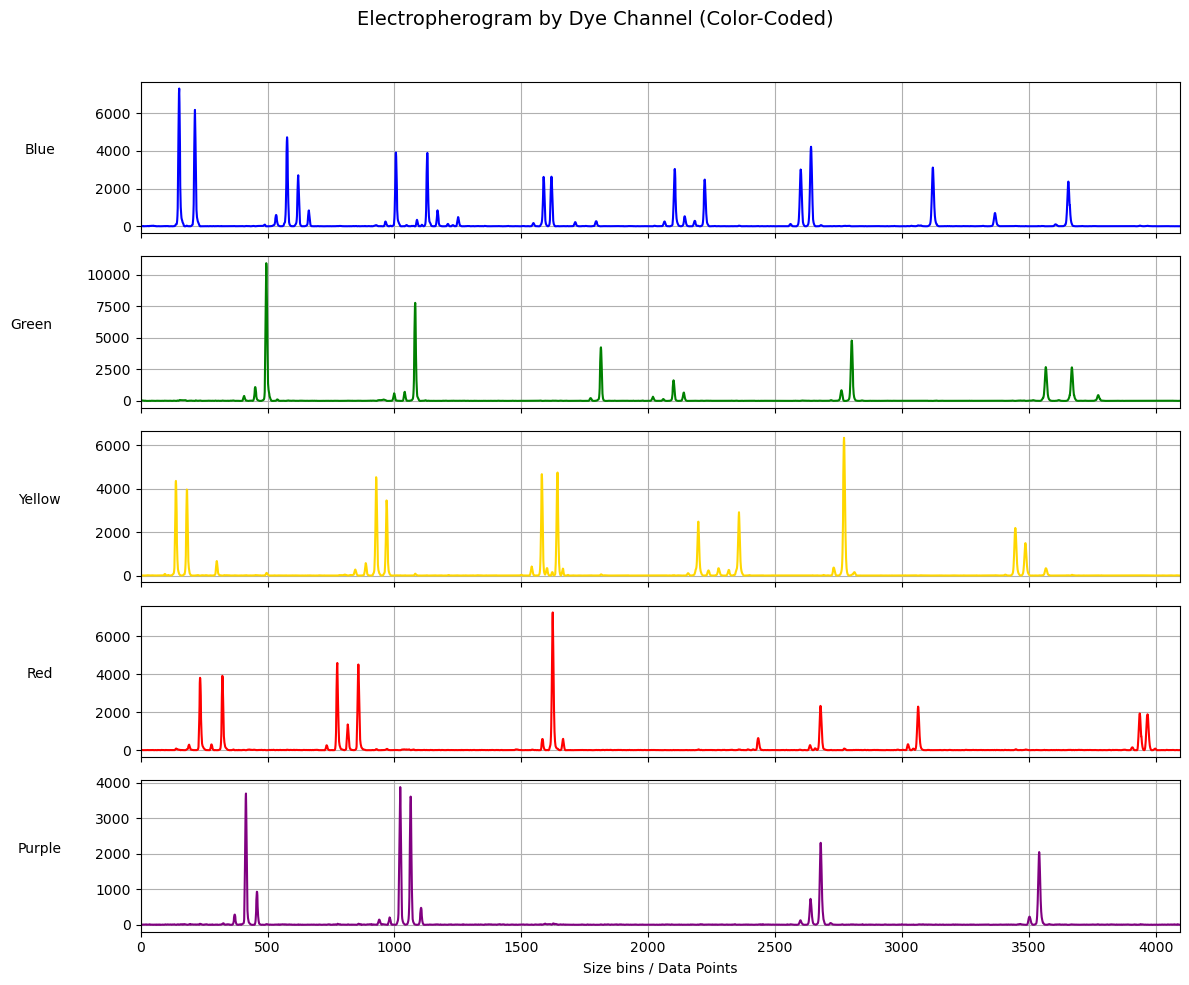

In [4]:
epg = image.data.squeeze()  # shape: (5, 4096)

dye_labels = ['Blue', 'Green', 'Yellow', 'Red', 'Purple']
dye_colors = ['blue', 'green', 'gold', 'red', 'purple']

fig, axs = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

for i in range(5):
    axs[i].plot(epg[i], color=dye_colors[i])
    axs[i].set_ylabel(dye_labels[i], rotation=0, labelpad=40, fontsize=10)
    axs[i].grid(True)
    axs[i].set_xlim(0, epg.shape[1])

axs[-1].set_xlabel("Size bins / Data Points")
plt.suptitle("Electropherogram by Dye Channel (Color-Coded)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Local Datasets

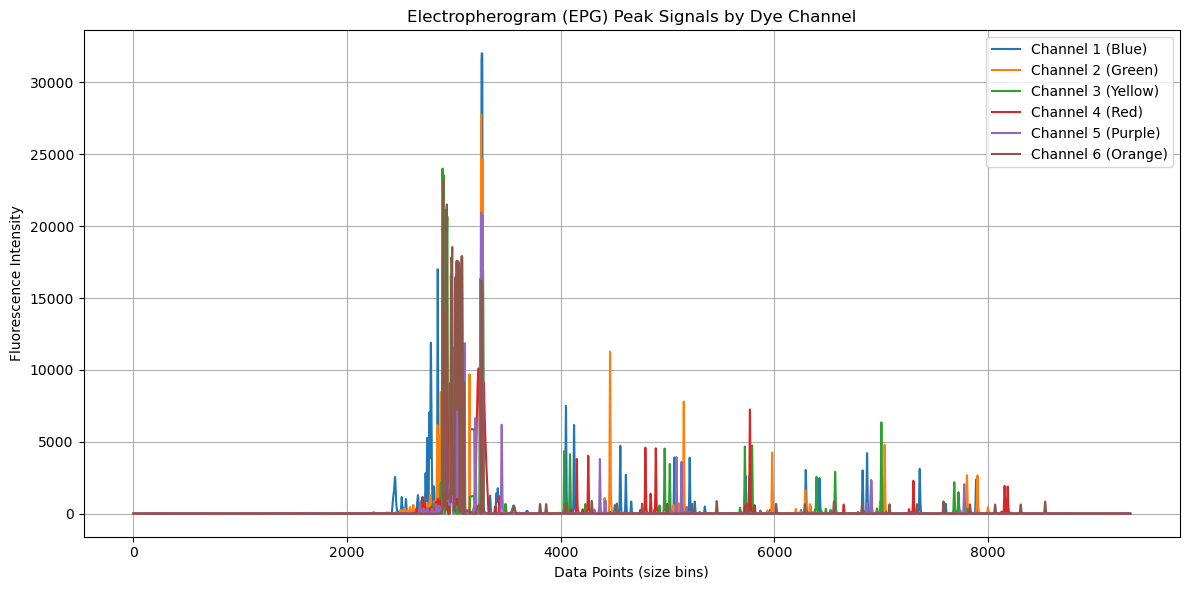

In [5]:
from DNAnet.data.parsing.parse_raw_hid import get_peak_data


epg = get_peak_data(image.path) # shape: (6, 4096)

def plot_epg_together(epg):
    plt.figure(figsize=(12, 6))
    dye_labels = ['Blue', 'Green', 'Yellow', 'Red', 'Purple', 'Orange']  # Optional: adjust per your kit

    for i in range(epg.shape[0]):
        plt.plot(epg[i], label=f'Channel {i+1} ({dye_labels[i]})')

    plt.xlabel("Data Points (size bins)")
    plt.ylabel("Fluorescence Intensity")
    plt.title("Electropherogram (EPG) Peak Signals by Dye Channel")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_epg_together(epg)